In [2]:
print("ready")

ready


In [3]:
print("ready")

ready


In [4]:
import pandas as pd

df = pd.read_csv("student_data.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
len(df)

395

In [8]:
df['sex'].value_counts()

sex
F    208
M    187
Name: count, dtype: int64

In [9]:
df['G3'].mean()

np.float64(10.415189873417722)

In [10]:
df.groupby('sex')['G3'].mean()

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

In [11]:
df['passed'] = df['G3'] >= 10
df['passed'].value_counts()

passed
True     265
False    130
Name: count, dtype: int64

### Study Time vs Final Grade

This section analyzes the relationship between study time and the final grade (G3).

In [12]:
df.groupby('studytime')['G3'].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

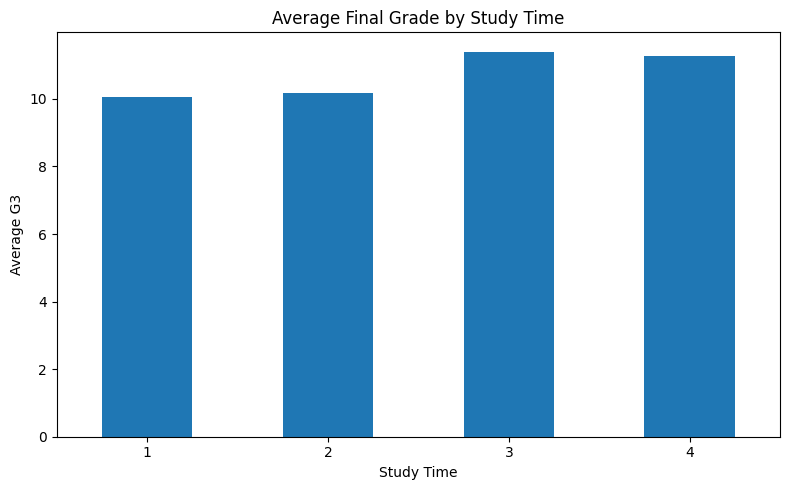

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.groupby('studytime')['G3'].mean().plot(kind='bar')
plt.title('Average Final Grade by Study Time')
plt.xlabel('Study Time')
plt.ylabel('Average G3')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The results show that students with higher study time categories tend to have higher average final grades. The highest average grades appear in study time categories 3 and 4, suggesting a positive relationship between study time and academic performance.

### Absences vs Final Grade

This section analyzes the relationship between student absences and the final grade (G3).

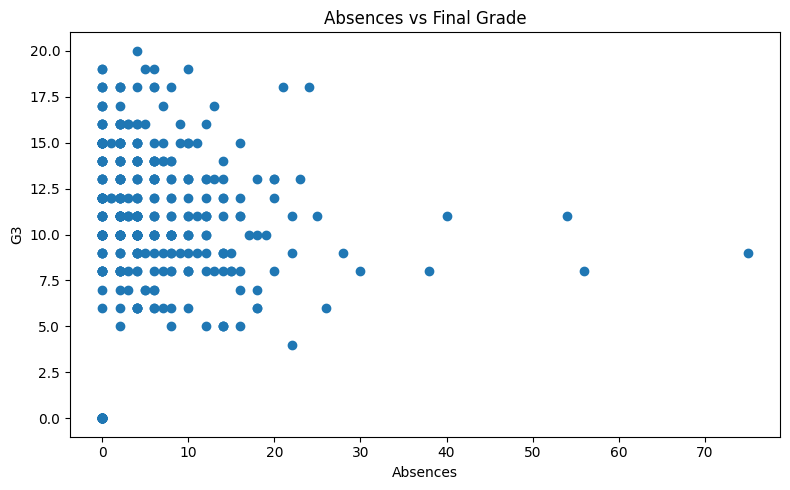

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['absences'], df['G3'])
plt.title('Absences vs Final Grade')
plt.xlabel('Absences')
plt.ylabel('G3')
plt.tight_layout()
plt.show()

The scatter plot shows that students with a higher number of absences tend to have lower final grades. Although the relationship is not perfectly linear, there is a general negative trend, suggesting that increased absences may negatively impact academic performance.

### Failures vs Final Grade

This section analyzes the relationship between the number of past class failures and the final grade (G3).

In [15]:
df.groupby('failures')['G3'].mean()

failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64

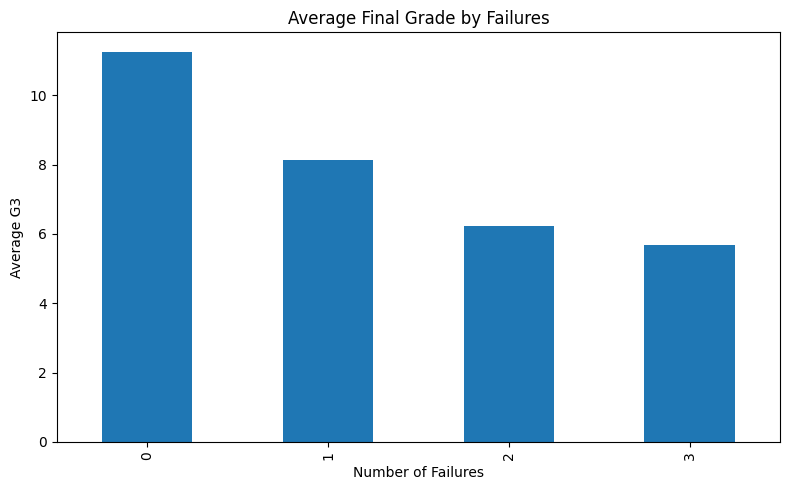

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.groupby('failures')['G3'].mean().plot(kind='bar')
plt.title('Average Final Grade by Failures')
plt.xlabel('Number of Failures')
plt.ylabel('Average G3')
plt.tight_layout()
plt.show()

The results show that students with fewer past failures tend to have higher final grades. As the number of failures increases, the average final grade decreases significantly. This indicates a strong negative relationship between past academic failures and current academic performance.

### Gender vs Final Grade

This section analyzes the relationship between student gender and the final grade (G3).

Text(0.5, 0, 'Gender')

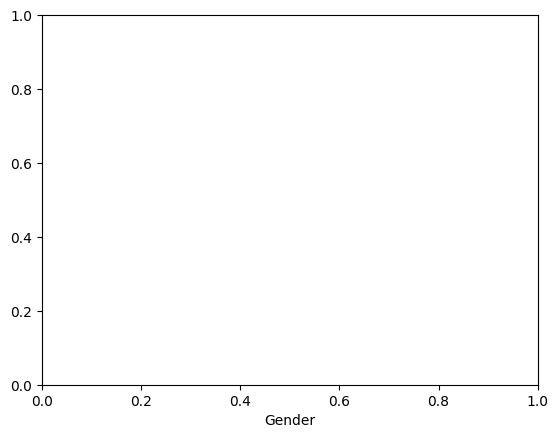

In [17]:
plt.xlabel('Gender')

## Conclusion

This project analyzed the factors affecting student performance using the dataset.

The analysis showed that:
- Students with higher study time tend to achieve better final grades.
- Absences have a negative impact on final grades.
- Gender does not significantly affect academic performance.

Overall, study habits appear to be the most important factor influencing student success.